In [201]:
import os
import json
import shutil
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, 
    classification_report,
    roc_curve, 
    auc, 
    roc_auc_score,
    accuracy_score
)
from sklearn.neighbors import KNeighborsClassifier
import torch
import torch.nn as nn
import torch.optim as optim

### Variable

In [17]:
DATA_DIR = "yelp_photos/photos"
SAMPLE_IMAGE_PATH = "images"
JSON_FILE = "yelp_photos/photos.json"

In [43]:
def load_metadata(json_file):
    with open(json_file, 'r') as f:
        data = [json.loads(line) for line in f]
    return pd.DataFrame(data)

# Function to Flatten Images (2D to 1D)
def flatten_images(images):
    return images.reshape(images.shape[0], -1)

In [19]:
yelp_df = load_metadata(JSON_FILE)
yelp_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [20]:
yelp_df.describe()

,photo_id,business_id,caption,label
count,200100,200100,200100,200100
unique,200098,36680,76413,5
top,_CYoxbCIKuAwpq4crHCPWg,FEXhWNCMkv22qG04E83Qjg,,food
freq,2,528,103366,108152


In [21]:
yelp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [22]:
yelp_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [23]:
# Label distribution
label_counts = yelp_df['label'].value_counts()
label_counts

label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64

In [24]:
yelp_df.count()

photo_id       200100
business_id    200100
caption        200100
label          200100
dtype: int64

In [25]:
df = yelp_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), int(len(x) * 0.1)))
)

df['label'].value_counts()

label
food       10815
inside      5603
outside     1856
drink       1567
menu         167
Name: count, dtype: int64

In [26]:
df.head()

,photo_id,business_id,caption,label
113110,3lCwrZlZpkCNyAcABPuMpw,qkMMkIdghXUiN7eMNSpiHg,,drink
77568,0CzsGcVSXznw7vZ22JjFbg,zLa1ItT12xW4gDmlHE0sIA,,drink
110388,4V7oGBwx76v-3pgnaObvZw,ERl6OCSEIFBOqfjai_jIUg,,drink
50897,rtGgTvwyQA42J3wL4kCeaA,UiZ2-Zq1SqZAC5HnfNNZFA,Pietro's,drink
5290,rlkFZvW-LbHrFfKm3OXQ1g,FEBwxZMEpxRwVXx9Fm0XZw,,drink


In [27]:
output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

for photo_id in df["photo_id"]:
    src = os.path.join(DATA_DIR, f"{photo_id}.jpg")
    dest = os.path.join(output_dir, f"{photo_id}.jpg")
    
    if os.path.exists(src) and not os.path.exists(dest):
        shutil.copy(src, dest)

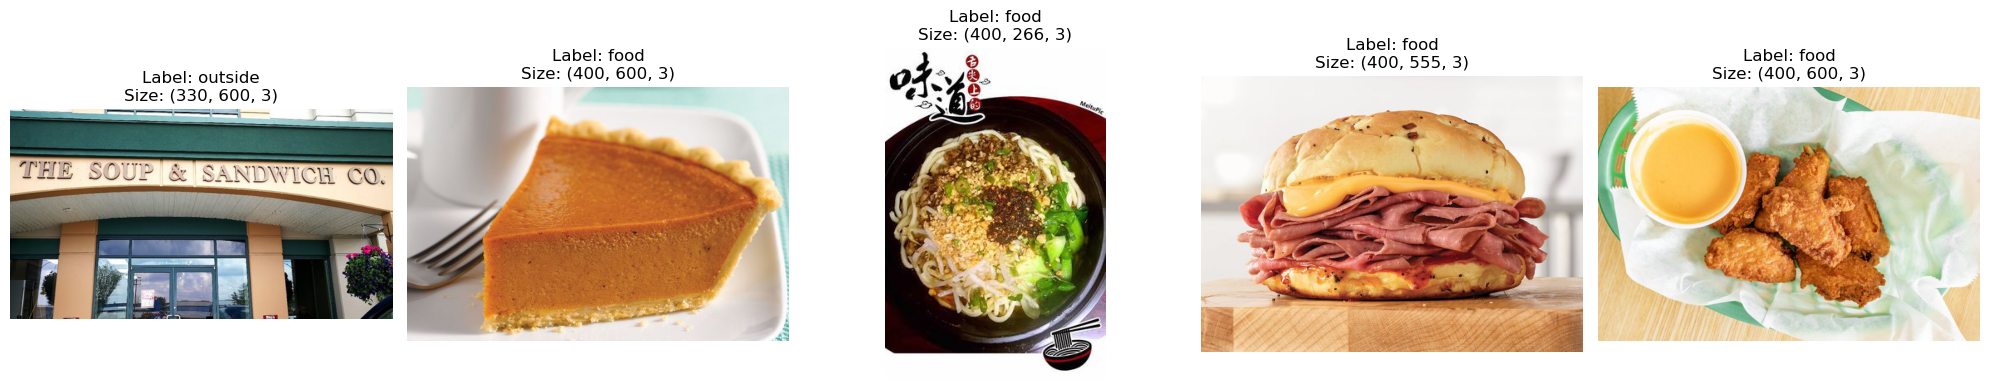

In [28]:
sample_df = df.sample(n=5, random_state=42)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join('images', f"{row['photo_id']}.jpg")
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Label: {row['label']}\nSize: {img.shape}")
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Process Images / normalize image

In [29]:
def process_images(photo_ids, img_dir, target_size = (64, 64)):
    processed_images = []
    missing_ids = []
    for photo_id in photo_ids:
         # Construct full input path
        image_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            image = Image.open(image_path)
            image_resized = image.resize(target_size)
            image_resized = np.array(image_resized)
            image_normalized = image_resized / 255.0
            processed_images.append(image_normalized)
        except Exception as e:
            missing_ids.append(photo_id)
            print(f"Error processing image {image_path}: {e}")
    print(f"Missing or corrupt images: {len(missing_ids)}")
    return np.array(processed_images), missing_ids

In [30]:
X, missing_ids = process_images(df["photo_id"], "images")

Error processing image images/1MOGQBWogR8oJr1WgERi9g.jpg: cannot identify image file 'images/1MOGQBWogR8oJr1WgERi9g.jpg'
Error processing image images/QRUo4vqUu3X9V4eIqBpY8A.jpg: cannot identify image file 'images/QRUo4vqUu3X9V4eIqBpY8A.jpg'
Error processing image images/NKEFWvRriK-LvagPz2QRxw.jpg: cannot identify image file 'images/NKEFWvRriK-LvagPz2QRxw.jpg'
Error processing image images/9RDbbAZB0HnL4hndCWB58w.jpg: cannot identify image file 'images/9RDbbAZB0HnL4hndCWB58w.jpg'
Error processing image images/rIhUkEmP-j4NcQVW3YuPYQ.jpg: cannot identify image file 'images/rIhUkEmP-j4NcQVW3YuPYQ.jpg'
Error processing image images/1wd_eyhMrTqUmicDmn4_Kw.jpg: cannot identify image file 'images/1wd_eyhMrTqUmicDmn4_Kw.jpg'
Error processing image images/-NGY_19QK2zq913HdiYc5A.jpg: cannot identify image file 'images/-NGY_19QK2zq913HdiYc5A.jpg'
Missing or corrupt images: 7


In [31]:
X.shape

(20001, 64, 64, 3)

In [32]:
df_filtered = df[~df["photo_id"].isin(missing_ids)].reset_index(drop=True)

In [33]:
df_filtered.shape

(20001, 4)

In [34]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_filtered["label"])

In [35]:
y.shape

(20001,)

In [36]:
def apply_histogram_equalization(images):
    equalized_images = []

    for image in images:
        # Convert from float (0-1) to uint8 (0-255)
        image_uint8 = (image * 255).astype(np.uint8)

        # Convert to grayscale before applying histogram equalization
        gray_image = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)

        # Apply histogram equalization
        equalized_image = cv2.equalizeHist(gray_image)
        equalized_images.append(equalized_image)

    return np.array(equalized_images)

if X.size > 0:
    equalized_images = apply_histogram_equalization(X)
    print(f"Successfully processed and equalized {len(equalized_images)} images.")
else:
    print("No valid images were processed.")

Successfully processed and equalized 20001 images.


In [37]:
# Gaussian Blur (Reduce Noise)
def apply_gaussian_blur(images, kernel_size=(5, 5)):
    blurred_images = []

    for image in images:
        # Convert from float (0-1) to uint8 (0-255)
        image_uint8 = (image * 255).astype(np.uint8)

        # Apply Gaussian Blur
        blurred_image = cv2.GaussianBlur(image_uint8, kernel_size, sigmaX=0)
        blurred_images.append(blurred_image)

    return np.array(blurred_images)

if X.size > 0:
    equalized_images = apply_histogram_equalization(X)
    blurred_images = apply_gaussian_blur(X)

    print(f"Successfully processed {len(equalized_images)} equalized images.")
    print(f"Successfully processed {len(blurred_images)} blurred images.")
else:
    print("No valid images were processed.")

Successfully processed 20001 equalized images.
Successfully processed 20001 blurred images.


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 16000, Testing samples: 4001


## kNN Model

In [47]:
knn = KNeighborsClassifier(n_neighbors=5) 
knn.fit(X_train.reshape(len(X_train), -1), y_train)

# Predict on test set
y_pred = knn.predict(X_test.reshape(len(X_test), -1))

# Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.6716
              precision    recall  f1-score   support

           0       0.34      0.16      0.21       314
           1       0.74      0.87      0.80      2162
           2       0.61      0.56      0.58      1121
           3       0.08      0.03      0.04        33
           4       0.50      0.36      0.42       371

    accuracy                           0.67      4001
   macro avg       0.45      0.39      0.41      4001
weighted avg       0.64      0.67      0.65      4001



In [62]:
X_flatten_knn_train = flatten_images(X_train)
X_flatten_knn_test = flatten_images(X_test)
knn = KNeighborsClassifier(n_neighbors=5) 
knn.fit(X_train.reshape(len(X_flatten_knn_train), -1), y_train)

# Predict on test set
y_pred = knn.predict(X_test.reshape(len(X_flatten_knn_test), -1))

# Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.6716
              precision    recall  f1-score   support

           0       0.34      0.16      0.21       314
           1       0.74      0.87      0.80      2162
           2       0.61      0.56      0.58      1121
           3       0.08      0.03      0.04        33
           4       0.50      0.36      0.42       371

    accuracy                           0.67      4001
   macro avg       0.45      0.39      0.41      4001
weighted avg       0.64      0.67      0.65      4001



In [48]:
# Define hyperparameter grid
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

# Perform Grid Search
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train.reshape(len(X_train), -1), y_train)

# Best parameters & accuracy
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'n_neighbors': 11}
Best accuracy: 0.6926


## Confusion Matrix kNN

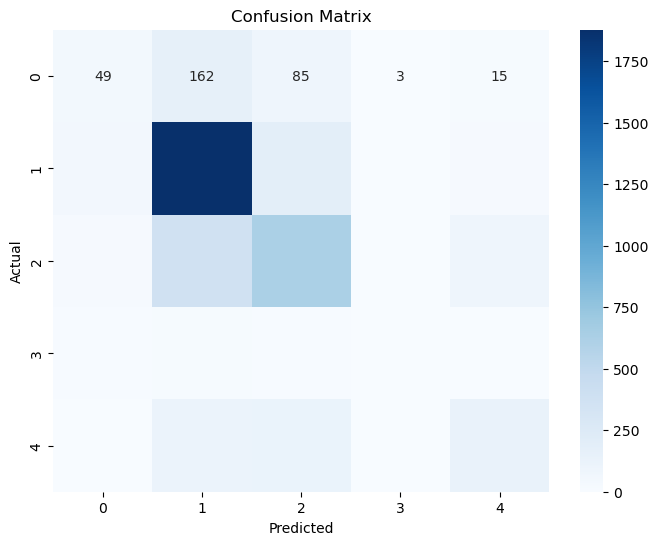

[[  49  162   85    3   15]
 [  56 1878  196    5   27]
 [  24  375  625    4   93]
 [   8   15    9    1    0]
 [   7  112  118    0  134]]


In [49]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(cm)

In [64]:
# Compute AUC Score (For multi-class, use OvR strategy)
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_pred_prob = knn.predict_proba(X_flatten_knn_test)
auc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class="ovr")
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7261


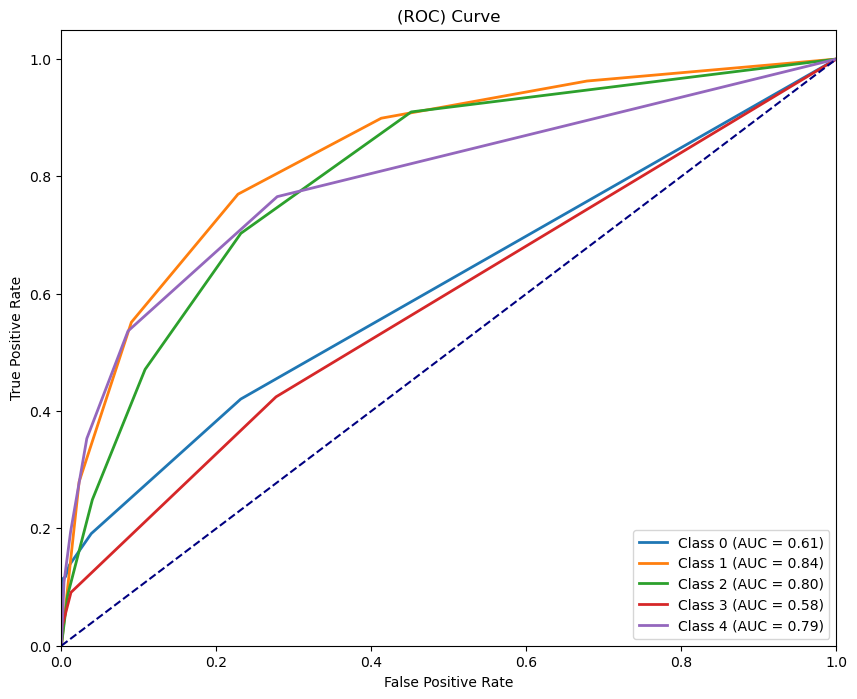

In [65]:
# Get probabilities for each class (One-vs-Rest)
y_prob = knn.predict_proba(X_flatten_knn_test.reshape(len(X_flatten_knn_test), -1))

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i in range(y_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])  # True labels for class i
    roc_auc = auc(fpr, tpr)  # Calculate AUC for each class
    
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## 3. Support Vector Machine (SVM) Model with Confusion Matrix and AUC

In [68]:
X_flattened_train = flatten_images(X_train)
X_flattened_test = flatten_images(X_test)

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flattened_train)
X_test_scaled = scaler.transform(X_flattened_test)

In [70]:
# Initialize SVM model
svm = SVC(kernel="rbf", probability=True, random_state=42, cache_size=2000, gamma="scale")

# Train the model
svm.fit(X_scaled, y_train)

# Predictions and confusion matrix
y_pred_svm = svm.predict(X_test_scaled)

In [71]:
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

In [72]:
conf_matrix_svm

array([[  34,  173,  101,    0,    6],
       [   1, 1960,  186,    0,   15],
       [   0,  214,  888,    0,   19],
       [   0,   20,   13,    0,    0],
       [   0,   78,  136,    0,  157]])

In [79]:
y_flatten_test = flatten_images(y_test)

In [77]:
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]  # Probability for positive class

In [89]:
unique_classes = np.unique(y_flatten_test)

In [90]:
unique_classes

array([0, 1, 2, 3, 4])

In [96]:
y_test_ravel = np.ravel(y_test)

In [91]:
y_test_bin = label_binarize(y_flatten_test, classes=unique_classes)

In [97]:
y_test_ravel

array([0, 1, 0, ..., 4, 2, 1])

In [105]:
unique_classes = np.unique(y_test_ravel)
print("Unique classes in y_test:", unique_classes)

# Step 3: Binarize the y_test labels (multi-class problem)
y_test_bin = label_binarize(y_test_ravel, classes=unique_classes)
print("Shape of y_test_bin:", y_test_bin.shape)

Unique classes in y_test: [0 1 2 3 4]
Shape of y_test_bin: (4001, 5)


In [106]:
y_test_bin

array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0]])

## DNN Model

In [144]:
X_flatten_dnn_train = flatten_images(X_train)
X_flatten_dnn_test = flatten_images(X_test)

In [162]:
y_train

array([1, 1, 2, ..., 1, 1, 1])

In [163]:
class DNN_Model(nn.Module):
    def __init__(self, input_size, num_classes):
        super(DNN_Model, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)  # First fully connected layer
        self.fc2 = nn.Linear(512, 256)         # Second fully connected layer
        self.fc3 = nn.Linear(256, num_classes)  # Output layer

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output layer (logits)
        return x

In [168]:
# Convert flattened data to torch tensors
X_train_tensor = torch.tensor(X_flatten_dnn_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_flatten_dnn_train, dtype=torch.long).squeeze()

In [176]:
X_test_tensor = torch.tensor(X_flatten_dnn_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_flatten_dnn_test, dtype=torch.long).squeeze()

In [169]:
# Define model, loss function, and optimizer
input_size = X_train_tensor.shape[1]  # Number of features in flattened images
num_classes = len(np.unique(y_train_tensor))  # Number of unique classes in y_train

In [170]:
model = DNN_Model(input_size, num_classes)
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [171]:
# Training Loop
epochs = 10
for epoch in range(epochs):
    model.train()
    
    # Zero the gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/10], Loss: 1.6475
Epoch [2/10], Loss: 3.4686
Epoch [3/10], Loss: 4.3060
Epoch [4/10], Loss: 1.1306
Epoch [5/10], Loss: 1.7139
Epoch [6/10], Loss: 1.7441
Epoch [7/10], Loss: 1.5499
Epoch [8/10], Loss: 1.1722
Epoch [9/10], Loss: 1.2087
Epoch [10/10], Loss: 1.2695


In [202]:
import time

# Training Loop with Detailed Information in the Same Line
epochs = 10
for epoch in range(epochs):
    model.train()

    # Start timing for the epoch
    start_time = time.time()

    # Zero the gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)
    
    # Calculate loss
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    # Measure the time taken for the epoch
    epoch_time = time.time() - start_time

    # Get the predicted class labels (with the highest probability)
    _, predicted = torch.max(outputs.data, 1)

    # Print all details in the same line
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | "
          f"Time: {epoch_time:.4f}s")

Epoch [1/10] | Loss: 1.0014 | Time: 3.2259s
Epoch [2/10] | Loss: 0.9846 | Time: 0.5847s
Epoch [3/10] | Loss: 0.9780 | Time: 0.5340s
Epoch [4/10] | Loss: 0.9863 | Time: 0.5332s
Epoch [5/10] | Loss: 0.9748 | Time: 0.5346s
Epoch [6/10] | Loss: 0.9687 | Time: 0.5391s
Epoch [7/10] | Loss: 0.9704 | Time: 0.5394s
Epoch [8/10] | Loss: 0.9598 | Time: 0.5311s
Epoch [9/10] | Loss: 0.9599 | Time: 0.5719s
Epoch [10/10] | Loss: 0.9595 | Time: 0.5707s


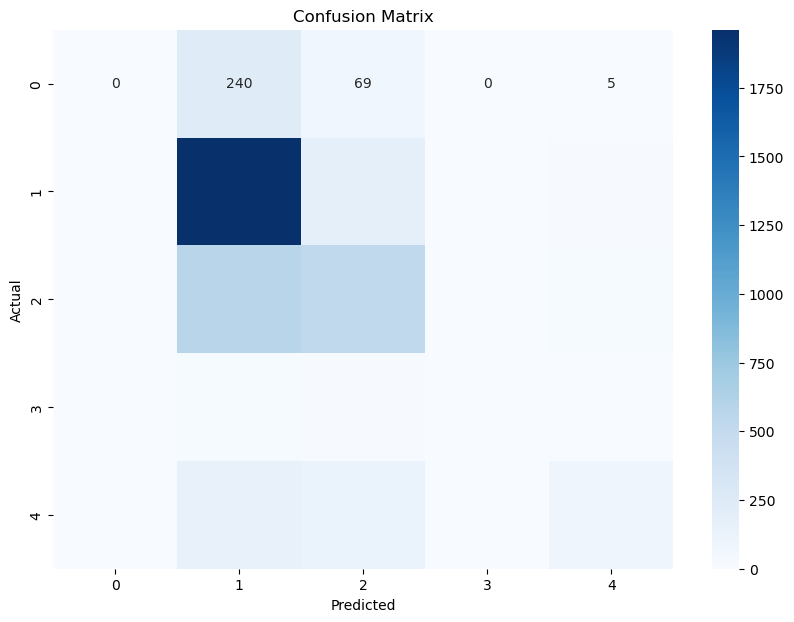

In [199]:
model_dnn.eval()  # Set the model to evaluation mode

with torch.no_grad():  # No need for gradients during evaluation
    outputs = model(X_test_tensor)
    
# Convert outputs to predicted class labels
_, predicted = torch.max(outputs, 1)

# Confusion Matrix
cm = confusion_matrix(y_test_tensor.numpy(), predicted.numpy())

# Plotting Confusion Matrix
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=np.unique(y_test_tensor.cpu()), 
                yticklabels=np.unique(y_test_tensor.cpu()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [185]:
# AUC Calculation (for multi-class, use one-vs-rest approach)
# Convert the labels and predictions to probabilities
y_test_one_hot = label_binarize(y_test_tensor.numpy(), classes=np.unique(y_test_tensor.numpy()))
y_pred_prob = torch.nn.functional.softmax(outputs, dim=1).numpy()

# Calculate the AUC for each class
fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

# Print AUC score
print(f"AUC: {roc_auc:.4f}")

AUC: 0.8788


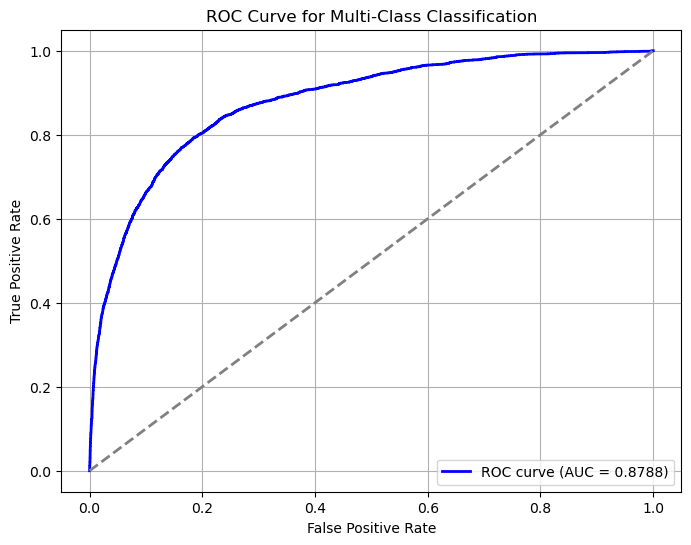

In [190]:
model.eval()  # Set the model to evaluation mode

with torch.no_grad():  # No need for gradients during evaluation
    outputs = model(X_test_tensor)
    
# Convert outputs to probabilities (use softmax for multi-class)
y_pred_prob = torch.nn.functional.softmax(outputs, dim=1).numpy()

# Binarize the true labels (if multi-class)
y_test_one_hot = label_binarize(y_test_tensor.numpy(), classes=np.unique(y_test_tensor.numpy()))

# Calculate ROC curve for each class
fpr, tpr, thresholds = roc_curve(y_test_one_hot.ravel(), y_pred_prob.ravel())

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal line (chance level)
plt.title('ROC Curve for Multi-Class Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()